In [13]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [14]:
class GreetState(BaseModel):
    message:str = ""

In [15]:
graph = StateGraph(GreetState)

In [16]:
### Nodes - Python Functions

In [17]:
def Greet(state:GreetState):
    state.message = f'{state.message} ! All is Good !'
    return state

In [18]:
def UpperCase(state:GreetState):
    state.message = state.message.upper()
    return state

In [19]:
graph.add_node("greet" , Greet)
graph.add_node("upper" , UpperCase)

In [20]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper")
graph.add_edge("upper", END)

In [21]:
finalGraph = graph.compile()

In [22]:
res = finalGraph.invoke({"message":"I love LangGraph !"}) # type: ignore

In [23]:
res

{'message': 'I LOVE LANGGRAPH ! ! ALL IS GOOD !'}

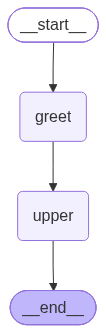

In [24]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())